# 🧠 Redes Neurais Convolucionais (CNNs) na Prática

**Aula prática — Deep Learning com PyTorch**

---

### 📚 Roteiro da aula

1. **Operação de convolução e pooling** — entendendo a matemática por trás
2. **Arquiteturas clássicas** — LeNet, VGG, ResNet
3. **Implementação em PyTorch** — laboratório guiado
4. **Transfer learning e fine-tuning** — aproveitando modelos pré-treinados
5. **🎯 Exercício final** — para fixar o conteúdo

---

> 💡 **Dica:** Antes de começar, vá em `Ambiente de execução → Alterar tipo de ambiente de execução → GPU`. As CNNs treinam **muito** mais rápido com GPU!


## 🔧 Setup inicial

Vamos importar as bibliotecas necessárias. O PyTorch já vem instalado no Colab, então não precisamos instalar nada manualmente.


In [ ]:
# Bibliotecas básicas de Python para manipulação de dados e visualização
import numpy as np                    # Operações numéricas com arrays
import matplotlib.pyplot as plt       # Visualização de gráficos e imagens
from PIL import Image                 # Manipulação de imagens

# PyTorch — framework de deep learning que vamos usar
import torch                          # Núcleo do PyTorch (tensores)
import torch.nn as nn                 # Módulos para construir redes neurais (camadas)
import torch.nn.functional as F       # Funções como ativações, convolução, etc.
import torch.optim as optim           # Otimizadores (SGD, Adam, etc.)



In [ ]:
# Torchvision — extensão do PyTorch focada em visão computacional
import torchvision                    # Módulo principal
import torchvision.transforms as transforms  # Transformações em imagens (resize, normalize, etc.)
from torchvision import datasets, models      # Datasets prontos (MNIST, CIFAR) e modelos pré-treinados

# DataLoader — facilita carregar dados em batches durante o treino
from torch.utils.data import DataLoader

# Verifica se temos GPU disponível. Se sim, usa CUDA; se não, usa CPU.
# .to(device) move tensores e modelos para o dispositivo escolhido.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {device}')
print(f'Versão do PyTorch: {torch.__version__}')

# Define uma seed para reprodutibilidade — todo mundo terá os mesmos resultados
torch.manual_seed(42)
np.random.seed(42)

---
# 📐 Parte 1 — A operação de convolução e pooling

## O que é uma convolução?

Uma **convolução** é uma operação que aplica um pequeno filtro (também chamado de **kernel**) sobre uma imagem, deslizando esse filtro pixel a pixel. Em cada posição, multiplicamos os valores do filtro pelos pixels correspondentes e somamos tudo, gerando um único número de saída.

**Por que usar convoluções em vez de redes totalmente conectadas?**

- 🎯 **Compartilhamento de parâmetros:** o mesmo filtro é aplicado em toda a imagem → menos parâmetros pra treinar
- 🌐 **Invariância à translação:** detecta padrões independente de onde estão na imagem
- 🔍 **Hierarquia de features:** primeiras camadas detectam bordas, camadas mais profundas detectam formas e objetos

### Fórmula do tamanho de saída

Para uma entrada de tamanho $W$, kernel de tamanho $K$, padding $P$ e stride $S$:

$$W_{out} = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1$$


### 🔬 Vamos visualizar uma convolução na prática

Vamos criar uma imagem simples e aplicar diferentes filtros para ver o que acontece.


Shape da imagem: torch.Size([1, 1, 20, 20])


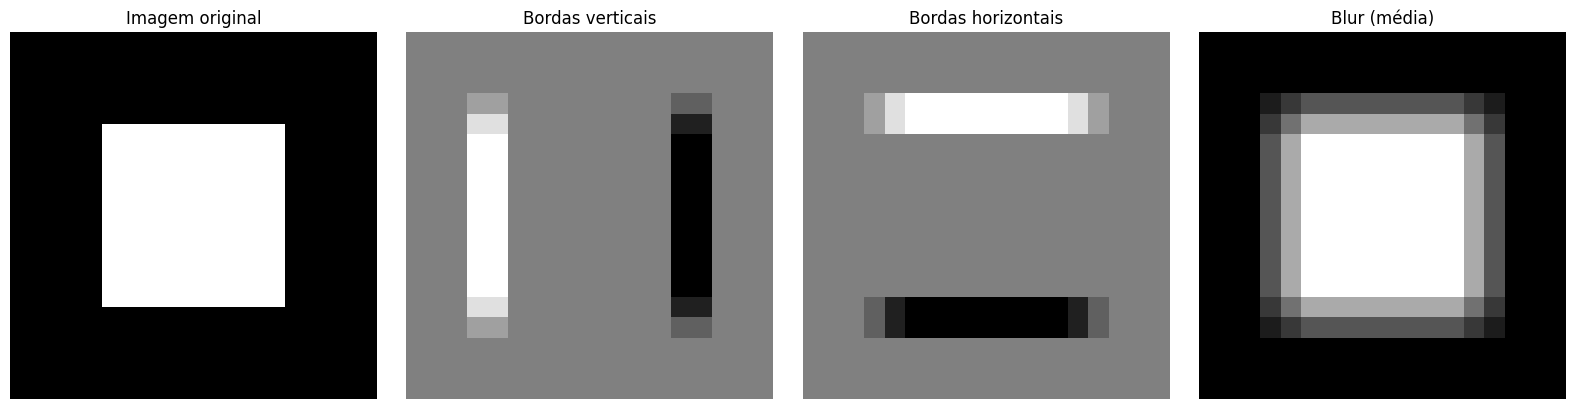

Tamanho da saída: torch.Size([1, 1, 18, 18])


In [2]:
# Cria uma imagem 2D sintética: um quadrado branco no meio de fundo preto
# Isso facilita ver como cada filtro responde a bordas
imagem = np.zeros((20, 20), dtype=np.float32)  # Fundo preto (zeros) 20x20
imagem[5:15, 5:15] = 1.0                        # Quadrado branco no centro

# Converte numpy array → tensor PyTorch
# Precisamos do formato (batch, channels, height, width) — por isso os unsqueeze
# unsqueeze(0) adiciona uma dimensão no início → forma o "batch" e depois o "canal"
imagem_tensor = torch.from_numpy(imagem).unsqueeze(0).unsqueeze(0)
print(f'Shape da imagem: {imagem_tensor.shape}')  # [1, 1, 20, 20]

# Definindo 3 filtros (kernels) clássicos de processamento de imagens

# Filtro 1: Detector de bordas verticais (Sobel vertical)
# Realça transições da esquerda pra direita
kernel_vertical = torch.tensor([[[[-1, 0, 1],
                                   [-2, 0, 2],
                                   [-1, 0, 1]]]], dtype=torch.float32)

# Filtro 2: Detector de bordas horizontais (Sobel horizontal)
kernel_horizontal = torch.tensor([[[[-1, -2, -1],
                                     [ 0,  0,  0],
                                     [ 1,  2,  1]]]], dtype=torch.float32)

# Filtro 3: Filtro de borramento (blur) — média 3x3
kernel_blur = torch.ones((1, 1, 3, 3), dtype=torch.float32) / 9.0

# Aplica cada filtro usando F.conv2d
# F.conv2d(entrada, peso) — operação de convolução 2D do PyTorch
saida_vertical = F.conv2d(imagem_tensor, kernel_vertical)
saida_horizontal = F.conv2d(imagem_tensor, kernel_horizontal)
saida_blur = F.conv2d(imagem_tensor, kernel_blur)

# Visualizando os resultados
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(imagem, cmap='gray');           axes[0].set_title('Imagem original')
axes[1].imshow(saida_vertical[0, 0], cmap='gray');   axes[1].set_title('Bordas verticais')
axes[2].imshow(saida_horizontal[0, 0], cmap='gray'); axes[2].set_title('Bordas horizontais')
axes[3].imshow(saida_blur[0, 0], cmap='gray');       axes[3].set_title('Blur (média)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Tamanho da saída: {saida_vertical.shape}')  # [1, 1, 18, 18] — diminuiu por causa do kernel 3x3

### 🏊 Pooling: reduzindo a dimensão espacial

O **pooling** reduz a dimensionalidade dos mapas de features. Os dois tipos mais comuns:

- **Max Pooling**: pega o valor máximo de cada região → preserva features mais "ativas"
- **Average Pooling**: pega a média de cada região → suaviza a saída

**Por que usar pooling?**
- ✂️ Reduz o número de parâmetros nas camadas seguintes
- 🎯 Adiciona pequena invariância a translações
- 🚀 Acelera o treinamento


Antes do pooling: torch.Size([1, 1, 18, 18])
Após max pool:    torch.Size([1, 1, 9, 9])
Após avg pool:    torch.Size([1, 1, 9, 9])


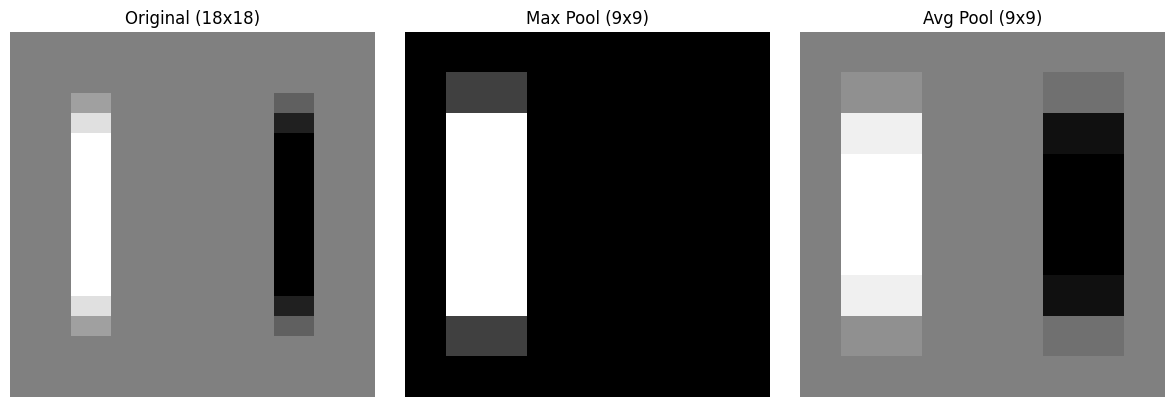

In [3]:
# Vamos aplicar pooling no resultado da convolução vertical
# Max pooling com janela 2x2 e stride 2 → reduz a dimensão pela metade
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

# Aplica os dois tipos de pooling
saida_max = max_pool(saida_vertical)
saida_avg = avg_pool(saida_vertical)

print(f'Antes do pooling: {saida_vertical.shape}')  # [1, 1, 18, 18]
print(f'Após max pool:    {saida_max.shape}')        # [1, 1, 9, 9]
print(f'Após avg pool:    {saida_avg.shape}')        # [1, 1, 9, 9]

# Visualização lado a lado
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(saida_vertical[0, 0], cmap='gray');  axes[0].set_title('Original (18x18)')
axes[1].imshow(saida_max[0, 0], cmap='gray');       axes[1].set_title('Max Pool (9x9)')
axes[2].imshow(saida_avg[0, 0], cmap='gray');       axes[2].set_title('Avg Pool (9x9)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

---
# 🏛️ Parte 2 — Arquiteturas clássicas de CNNs

Ao longo da história do deep learning, várias arquiteturas marcaram época. Vamos conhecer três delas:

| Arquitetura | Ano | Autores | Inovação principal |
|-------------|-----|---------|--------------------|
| **LeNet-5** | 1998 | LeCun et al. | Primeira CNN bem-sucedida (dígitos) |
| **VGG** | 2014 | Simonyan & Zisserman | Profundidade com filtros 3x3 |
| **ResNet** | 2015 | He et al. | Conexões residuais (skip connections) |


## 🔢 LeNet-5 — A pioneira

A LeNet-5 foi criada por Yann LeCun para reconhecer dígitos manuscritos (CEPs em envelopes!). Apesar de simples, ela introduziu a estrutura básica que todas as CNNs modernas seguem:

```
INPUT → [CONV → POOL] × N → FC → OUTPUT
```

**Estrutura:**
- 2 camadas convolucionais (com pooling após cada uma)
- 3 camadas totalmente conectadas (fully connected)


In [4]:
class LeNet5(nn.Module):
    """
    Implementação da LeNet-5 adaptada para imagens 28x28 (MNIST).
    A original era para 32x32, mas a estrutura é a mesma.
    """

    def __init__(self, num_classes=10):
        # super().__init__() é OBRIGATÓRIO em todo módulo do PyTorch
        # Ele inicializa a classe pai (nn.Module) corretamente
        super().__init__()

        # ---------- Bloco convolucional ----------
        # Conv2d(canais_entrada, canais_saída, tamanho_kernel, padding)
        # padding=2 mantém o tamanho espacial igual após a convolução 5x5

        # 1ª conv: 1 canal (cinza) → 6 mapas de features, kernel 5x5
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)

        # 2ª conv: 6 → 16 mapas de features, kernel 5x5 (sem padding agora)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)

        # Pooling reusável — reduz o tamanho espacial pela metade
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ---------- Bloco totalmente conectado ----------
        # Após as 2 convs+pools, o tensor tem shape (16, 5, 5) — total 16*5*5 = 400 neurônios
        self.fc1 = nn.Linear(16 * 5 * 5, 120)   # primeira camada densa
        self.fc2 = nn.Linear(120, 84)            # segunda camada densa
        self.fc3 = nn.Linear(84, num_classes)    # saída — uma logit por classe

    def forward(self, x):
        """
        Define o fluxo dos dados pela rede (forward pass).
        x: tensor de entrada com shape [batch, 1, 28, 28]
        """
        # Bloco 1: conv → ativação ReLU → pooling
        # Após: [batch, 6, 14, 14]
        x = self.pool(F.relu(self.conv1(x)))

        # Bloco 2: conv → ReLU → pooling
        # Após: [batch, 16, 5, 5]
        x = self.pool(F.relu(self.conv2(x)))

        # Achata o tensor para passar nas camadas densas
        # view(-1, ...) preserva o batch e achata o resto
        x = x.view(-1, 16 * 5 * 5)

        # Camadas densas com ativação ReLU
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # saída sem ativação — usaremos CrossEntropyLoss

        return x

# Cria uma instância do modelo e mostra a arquitetura
modelo_lenet = LeNet5()
print(modelo_lenet)

# Testa com um tensor falso pra ver se as dimensões batem
entrada_teste = torch.randn(1, 1, 28, 28)  # batch=1, 1 canal, 28x28
saida_teste = modelo_lenet(entrada_teste)
print(f'\nShape de entrada: {entrada_teste.shape}')
print(f'Shape de saída:   {saida_teste.shape}')  # [1, 10] — 10 classes

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Shape de entrada: torch.Size([1, 1, 28, 28])
Shape de saída:   torch.Size([1, 10])


## 🏗️ VGG — Vai fundo!

A VGG mostrou que **profundidade importa**. A ideia é simples mas poderosa: empilhar várias convoluções 3x3 seguidas, em vez de usar filtros maiores.

**Por que filtros 3x3?**
- Duas convs 3x3 empilhadas têm o mesmo "campo receptivo" de uma 5x5, mas com **menos parâmetros** e **mais não-linearidades**
- Mais blocos → mais capacidade de abstração

Vamos implementar uma **mini-VGG** simplificada (a original tem 16 ou 19 camadas — pesado demais pra treinar em aula!).


In [5]:
class MiniVGG(nn.Module):
    """
    Versão reduzida da VGG, adequada para CIFAR-10 (32x32).
    Mantém a filosofia da VGG: blocos de convs 3x3 + pooling.
    """

    def __init__(self, num_classes=10):
        super().__init__()

        # nn.Sequential empacota várias camadas em ordem — bem prático!
        # Cada bloco: 2 convs 3x3 → ReLU → MaxPool

        # Bloco 1: 3 canais (RGB) → 64 features. Saída: 16x16
        self.bloco1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),    # mantém 32x32
            nn.ReLU(inplace=True),                          # inplace=True economiza memória
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)           # reduz pra 16x16
        )

        # Bloco 2: 64 → 128 features. Saída: 8x8
        self.bloco2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Bloco 3: 128 → 256 features. Saída: 4x4
        self.bloco3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classificador final — após os blocos, temos 256 canais x 4 x 4 = 4096 valores
        self.classificador = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),                # Dropout: zera 50% dos neurônios → reduz overfitting
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Passa pelos blocos convolucionais
        x = self.bloco1(x)
        x = self.bloco2(x)
        x = self.bloco3(x)

        # Achata para o classificador
        x = x.view(x.size(0), -1)  # x.size(0) é o tamanho do batch

        x = self.classificador(x)
        return x

# Teste rápido
mini_vgg = MiniVGG()
entrada = torch.randn(2, 3, 32, 32)  # batch de 2 imagens RGB 32x32
print(f'Saída: {mini_vgg(entrada).shape}')  # [2, 10]

# Conta o número de parâmetros — interessante comparar entre arquiteturas!
total_params = sum(p.numel() for p in mini_vgg.parameters())
print(f'Parâmetros totais da MiniVGG: {total_params:,}')

Saída: torch.Size([2, 10])
Parâmetros totais da MiniVGG: 3,248,202


## 🔁 ResNet — A revolução dos atalhos

Quando empilhamos muitas camadas, surge um problema: o **gradiente desaparece** durante o backpropagation, e a rede fica mais difícil de treinar — às vezes piora ao adicionar mais profundidade!

A **ResNet** resolveu isso com uma ideia genial: **conexões residuais** (skip connections).

Em vez de aprender uma função $H(x)$, a rede aprende a **diferença** $F(x) = H(x) - x$, e a saída é $F(x) + x$.

```
       ┌──────────────────────┐
   x ──┤                      │──► +  ──► saída
       │                      │   ↑
       └──► [Conv → Conv] ────┘  (soma com x)
```

Isso permitiu treinar redes **muito** profundas (até 152 camadas!) sem perder qualidade.


In [6]:
class BlocoResidual(nn.Module):
    """
    Bloco residual básico da ResNet.
    Estrutura: Conv → BN → ReLU → Conv → BN → (+ atalho) → ReLU
    """

    def __init__(self, canais_entrada, canais_saida, stride=1):
        super().__init__()

        # Primeira conv — pode reduzir o tamanho espacial se stride > 1
        self.conv1 = nn.Conv2d(canais_entrada, canais_saida, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        # Batch Normalization — estabiliza o treino e acelera a convergência
        self.bn1 = nn.BatchNorm2d(canais_saida)

        # Segunda conv — sempre stride=1
        self.conv2 = nn.Conv2d(canais_saida, canais_saida, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(canais_saida)

        # ---- Atalho (skip connection) ----
        # Se a entrada e saída têm shapes diferentes, precisamos ajustar o atalho
        # com uma convolução 1x1 — caso contrário, é só identidade.
        self.atalho = nn.Sequential()  # vazio = identidade
        if stride != 1 or canais_entrada != canais_saida:
            self.atalho = nn.Sequential(
                nn.Conv2d(canais_entrada, canais_saida, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(canais_saida)
            )

    def forward(self, x):
        # Caminho principal
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # AQUI ESTÁ A MÁGICA: somamos a entrada (atalho) à saída do bloco
        out = out + self.atalho(x)

        # ReLU final — aplicada DEPOIS da soma
        out = F.relu(out)
        return out


class MiniResNet(nn.Module):
    """
    Mini-ResNet para CIFAR-10. Arquitetura simplificada com 3 estágios de blocos residuais.
    """

    def __init__(self, num_classes=10):
        super().__init__()

        # Stem — primeira convolução que prepara as features
        self.conv_inicial = nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False)
        self.bn_inicial = nn.BatchNorm2d(64)

        # Estágios de blocos residuais
        # Estágio 1: 64 → 64, mantém 32x32
        self.estagio1 = self._criar_estagio(64, 64, num_blocos=2, stride=1)
        # Estágio 2: 64 → 128, reduz para 16x16
        self.estagio2 = self._criar_estagio(64, 128, num_blocos=2, stride=2)
        # Estágio 3: 128 → 256, reduz para 8x8
        self.estagio3 = self._criar_estagio(128, 256, num_blocos=2, stride=2)

        # Global Average Pooling — pega a média de cada mapa de features
        # Substitui as várias FCs gigantes da VGG → muito menos parâmetros!
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Classificador final
        self.fc = nn.Linear(256, num_classes)

    def _criar_estagio(self, canais_entrada, canais_saida, num_blocos, stride):
        """Helper que cria um estágio com vários blocos residuais."""
        camadas = []
        # Primeiro bloco do estágio pode ter stride > 1 (downsample)
        camadas.append(BlocoResidual(canais_entrada, canais_saida, stride))
        # Demais blocos sempre stride=1
        for _ in range(num_blocos - 1):
            camadas.append(BlocoResidual(canais_saida, canais_saida, stride=1))
        return nn.Sequential(*camadas)

    def forward(self, x):
        x = F.relu(self.bn_inicial(self.conv_inicial(x)))
        x = self.estagio1(x)
        x = self.estagio2(x)
        x = self.estagio3(x)
        x = self.avgpool(x)         # [batch, 256, 1, 1]
        x = x.view(x.size(0), -1)   # [batch, 256]
        x = self.fc(x)
        return x

# Testa
mini_resnet = MiniResNet()
print(f'Saída: {mini_resnet(torch.randn(2, 3, 32, 32)).shape}')
total_params = sum(p.numel() for p in mini_resnet.parameters())
print(f'Parâmetros totais da MiniResNet: {total_params:,}')

Saída: torch.Size([2, 10])
Parâmetros totais da MiniResNet: 2,777,674


---
# 🧪 Parte 3 — Laboratório PyTorch: treinando uma CNN no CIFAR-10

Agora que entendemos as arquiteturas, vamos treinar uma rede de verdade!

**CIFAR-10:** dataset com 60.000 imagens 32x32 coloridas, em 10 classes (avião, carro, pássaro, gato, cervo, cachorro, sapo, cavalo, barco, caminhão).


## 📥 Carregando o CIFAR-10

O torchvision já vem com vários datasets prontos. Vamos baixar o CIFAR-10 e aplicar **transformações** importantes:

- **Normalização:** centraliza os valores em torno de 0 → ajuda o treino convergir
- **Data augmentation (só no treino):** crop aleatório e flip horizontal → aumenta a variedade dos dados


In [7]:
# ===== Transformações de pré-processamento =====

# Para o conjunto de TREINO: usamos data augmentation
# Cada época, as imagens são levemente alteradas → o modelo aprende a generalizar mais
transform_treino = transforms.Compose([
    transforms.RandomCrop(32, padding=4),      # corta uma região aleatória 32x32 com 4 pixels de padding
    transforms.RandomHorizontalFlip(),         # inverte horizontalmente com 50% de chance
    transforms.ToTensor(),                     # converte PIL Image → Tensor [0, 1]
    transforms.Normalize(                      # normaliza com média e desvio padrão
        mean=(0.4914, 0.4822, 0.4465),         # médias dos canais R, G, B do CIFAR-10
        std=(0.2470, 0.2435, 0.2616)           # desvios padrão
    )
])

# Para o TESTE: NUNCA usar data augmentation! Queremos avaliar com dados "limpos"
transform_teste = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

# Baixa o CIFAR-10. Na 1ª vez ele é baixado; depois fica em cache.
trainset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_treino)
testset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_teste)

# DataLoader: divide o dataset em batches e embaralha (no treino)
# num_workers=2 carrega dados em paralelo
trainloader = DataLoader(trainset, batch_size=128, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=128, shuffle=False, num_workers=2)

# Nomes das classes — útil para visualização
classes = ('avião', 'carro', 'pássaro', 'gato', 'cervo',
           'cachorro', 'sapo', 'cavalo', 'barco', 'caminhão')

print(f'Imagens de treino: {len(trainset)}')
print(f'Imagens de teste:  {len(testset)}')

NameError: name 'transforms' is not defined

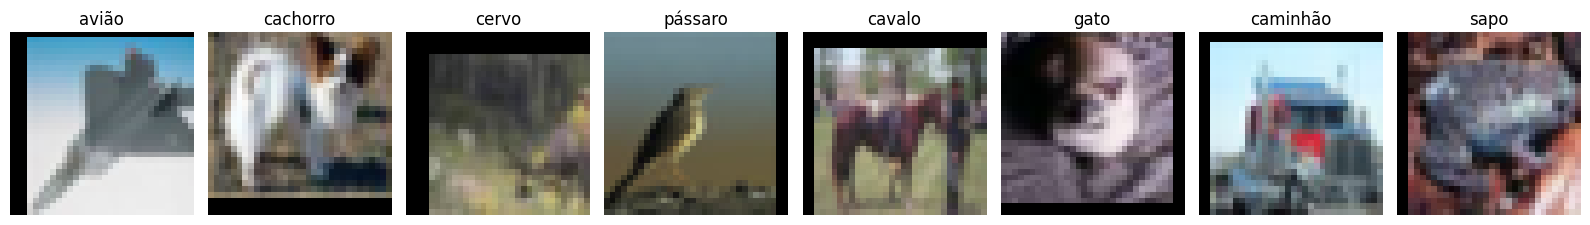

In [ ]:
# Vamos visualizar algumas imagens do dataset para conferir
# Pega um batch de exemplo
dataiter = iter(trainloader)
imagens, rotulos = next(dataiter)

# Função que "desnormaliza" para conseguirmos visualizar com cores corretas
def desnormalizar(img):
    """Reverte a normalização aplicada nas transformações."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return img * std + mean  # multiplicação e soma elemento a elemento

# Plota 8 imagens
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    img = desnormalizar(imagens[i])
    img = img.permute(1, 2, 0).numpy()  # [C, H, W] → [H, W, C] para matplotlib
    img = np.clip(img, 0, 1)            # garante que os valores fiquem em [0, 1]
    axes[i].imshow(img)
    axes[i].set_title(classes[rotulos[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 🏋️ Treinando a MiniVGG

Vamos treinar nossa MiniVGG no CIFAR-10. O processo de treino tem 3 ingredientes principais:

1. **Função de perda (loss):** `CrossEntropyLoss` para classificação multiclasse
2. **Otimizador:** `Adam` (escolha segura) ou `SGD` com momentum (clássico)
3. **Loop de treino:** itera várias vezes pelos dados (épocas)


In [ ]:
# Função de treinamento reutilizável — vamos usar nas várias seções
def treinar(modelo, trainloader, testloader, epochs=5, lr=0.001):
    """
    Treina um modelo e retorna o histórico de losses e acurácias.

    Args:
        modelo: rede neural (nn.Module)
        trainloader, testloader: DataLoaders dos dados
        epochs: número de passagens completas pelo dataset
        lr: learning rate (taxa de aprendizado)

    Returns:
        dict com 'train_loss', 'test_acc' por época
    """
    # Move o modelo para a GPU (se disponível)
    modelo = modelo.to(device)

    # Função de perda — combina LogSoftmax + NLLLoss internamente
    criterio = nn.CrossEntropyLoss()

    # Otimizador Adam — bom default que adapta a taxa de aprendizado por parâmetro
    otimizador = optim.Adam(modelo.parameters(), lr=lr)

    historico = {'train_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        # ===== Modo TREINO =====
        # IMPORTANTE: ativa Dropout e BatchNorm em modo treino
        modelo.train()
        loss_total = 0.0
        n_amostras = 0

        for imagens, rotulos in trainloader:
            # Move os dados pra GPU
            imagens, rotulos = imagens.to(device), rotulos.to(device)

            # ----- Passo 1: zerar os gradientes -----
            # PyTorch ACUMULA gradientes por padrão; precisamos zerar a cada batch
            otimizador.zero_grad()

            # ----- Passo 2: forward pass -----
            saidas = modelo(imagens)
            loss = criterio(saidas, rotulos)

            # ----- Passo 3: backward pass + atualização -----
            loss.backward()           # calcula os gradientes via autograd
            otimizador.step()         # atualiza os pesos com base nos gradientes

            # Acumula a loss (multiplicada pelo tamanho do batch)
            loss_total += loss.item() * imagens.size(0)
            n_amostras += imagens.size(0)

        loss_media = loss_total / n_amostras

        # ===== Modo AVALIAÇÃO =====
        # IMPORTANTE: desativa Dropout e usa as estatísticas acumuladas do BatchNorm
        modelo.eval()
        acertos = 0
        total = 0

        # torch.no_grad() desativa o cálculo de gradientes → mais rápido e menos memória
        with torch.no_grad():
            for imagens, rotulos in testloader:
                imagens, rotulos = imagens.to(device), rotulos.to(device)
                saidas = modelo(imagens)
                # argmax pega a classe com maior logit (= maior probabilidade)
                _, preditos = torch.max(saidas, dim=1)
                acertos += (preditos == rotulos).sum().item()
                total += rotulos.size(0)

        acuracia = 100.0 * acertos / total

        # Salva no histórico e imprime
        historico['train_loss'].append(loss_media)
        historico['test_acc'].append(acuracia)
        print(f'Época {epoch+1:2d}/{epochs} | Loss treino: {loss_media:.4f} | Acurácia teste: {acuracia:.2f}%')

    return historico


# Cria o modelo e treina
print('🚀 Treinando MiniVGG...')
modelo_vgg = MiniVGG(num_classes=10)
hist_vgg = treinar(modelo_vgg, trainloader, testloader, epochs=5, lr=0.001)

🚀 Treinando MiniVGG...
Época  1/5 | Loss treino: 1.7849 | Acurácia teste: 50.02%
Época  2/5 | Loss treino: 1.2819 | Acurácia teste: 61.64%
Época  3/5 | Loss treino: 1.0413 | Acurácia teste: 67.89%
Época  4/5 | Loss treino: 0.8969 | Acurácia teste: 72.77%
Época  5/5 | Loss treino: 0.7842 | Acurácia teste: 75.52%


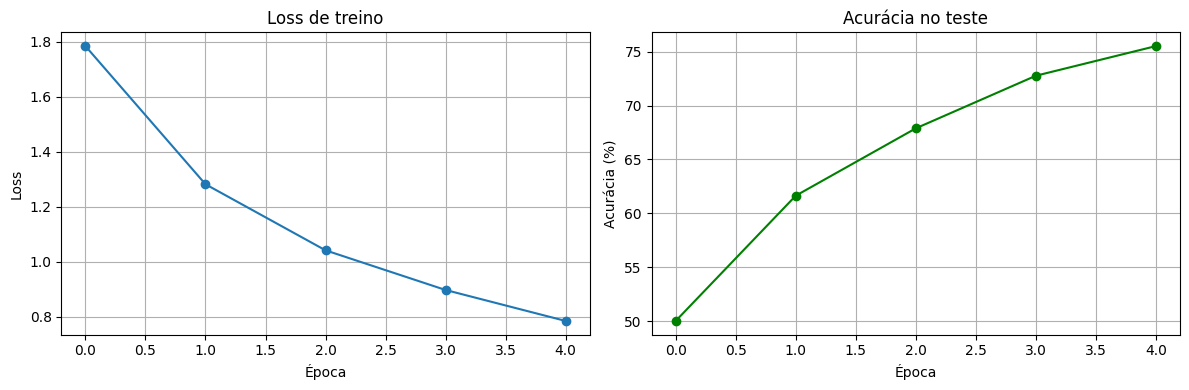

In [ ]:
# Visualiza as curvas de treinamento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_vgg['train_loss'], 'o-')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss de treino'); axes[0].grid(True)

axes[1].plot(hist_vgg['test_acc'], 'o-', color='green')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Acurácia (%)')
axes[1].set_title('Acurácia no teste'); axes[1].grid(True)

plt.tight_layout(); plt.show()

---
# 🚀 Parte 4 — Transfer Learning e Fine-tuning

## O que é Transfer Learning?

**Transfer learning** é a técnica de pegar um modelo **já treinado** em um dataset gigante (geralmente ImageNet, com 1.2 milhão de imagens) e aproveitá-lo para uma nova tarefa.

**Por que isso funciona tão bem?**
- 🧠 As camadas iniciais aprendem features genéricas (bordas, texturas, formas) que servem para qualquer imagem
- 💸 Treinar uma ResNet do zero exige horas/dias com várias GPUs — fazer fine-tuning leva minutos!
- 📊 Funciona MUITO bem mesmo com poucos dados de treino

### Duas estratégias principais

| Estratégia | Quando usar | Como faz |
|------------|-------------|----------|
| **Feature extraction** | Pouquíssimos dados, classes parecidas com ImageNet | Congela tudo, treina só a nova camada final |
| **Fine-tuning** | Dataset razoável, distribuição diferente | Descongela algumas camadas finais e treina com lr baixo |


In [ ]:
# Vamos carregar a ResNet18 pré-treinada no ImageNet
# weights=ResNet18_Weights.DEFAULT pega os melhores pesos disponíveis

# Carrega a ResNet18 com pesos do ImageNet
modelo_pretreinado = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Vamos inspecionar a estrutura da última camada
print('Camada final original (ImageNet tem 1000 classes):')
print(modelo_pretreinado.fc)
print(f'\nTotal de parâmetros: {sum(p.numel() for p in modelo_pretreinado.parameters()):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Camada final original (ImageNet tem 1000 classes):
Linear(in_features=512, out_features=1000, bias=True)

Total de parâmetros: 11,689,512


### Estratégia 1: Feature Extraction (congelar tudo)

Vamos congelar todas as camadas pré-treinadas e treinar apenas uma nova camada classificadora.


In [ ]:
# Para o transfer learning, precisamos redimensionar nossas imagens 32x32 para 224x224
# (tamanho que a ResNet espera). Também usamos as estatísticas do ImageNet pra normalização.

transform_imagenet = transforms.Compose([
    transforms.Resize(224),                     # redimensiona para 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],            # médias do ImageNet
        std=[0.229, 0.224, 0.225]              # desvios do ImageNet
    )
])

# Para deixar o exemplo rápido, vamos usar um SUBCONJUNTO menor do CIFAR-10
trainset_pequeno = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_imagenet)
testset_pequeno  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_imagenet)

# Pegando só uma fração dos dados (transfer learning brilha justamente quando temos pouco dado!)
from torch.utils.data import Subset
indices_treino = np.random.choice(len(trainset_pequeno), 2000, replace=False)
indices_teste  = np.random.choice(len(testset_pequeno),  1000, replace=False)

trainset_sub = Subset(trainset_pequeno, indices_treino)
testset_sub  = Subset(testset_pequeno,  indices_teste)

trainloader_tl = DataLoader(trainset_sub, batch_size=64, shuffle=True,  num_workers=2)
testloader_tl  = DataLoader(testset_sub,  batch_size=64, shuffle=False, num_workers=2)

print(f'Treino: {len(trainset_sub)} imagens, Teste: {len(testset_sub)} imagens')

Treino: 2000 imagens, Teste: 1000 imagens


In [ ]:
# ===== ESTRATÉGIA 1: Feature Extraction =====

# Recarrega o modelo pré-treinado
modelo_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Congela TODOS os parâmetros — eles não serão atualizados durante o treino
# requires_grad=False diz ao autograd para não calcular gradientes pra esses pesos
for param in modelo_fe.parameters():
    param.requires_grad = False

# SUBSTITUI a última camada (fc) por uma nova com 10 saídas (CIFAR-10)
# Como a nova camada tem requires_grad=True por default, só ela será treinada
num_features = modelo_fe.fc.in_features  # quantas features chegam na camada final (= 512 na ResNet18)
modelo_fe.fc = nn.Linear(num_features, 10)

# Conta parâmetros treináveis vs congelados
total = sum(p.numel() for p in modelo_fe.parameters())
treinaveis = sum(p.numel() for p in modelo_fe.parameters() if p.requires_grad)
print(f'Parâmetros totais:     {total:,}')
print(f'Parâmetros treináveis: {treinaveis:,} ({100*treinaveis/total:.2f}%)')
print('→ Vamos treinar APENAS a última camada!\n')

# Treina
print('🚀 Treinando com Feature Extraction...')
hist_fe = treinar(modelo_fe, trainloader_tl, testloader_tl, epochs=3, lr=0.001)

Parâmetros totais:     11,181,642
Parâmetros treináveis: 5,130 (0.05%)
→ Vamos treinar APENAS a última camada!

🚀 Treinando com Feature Extraction...
Época  1/3 | Loss treino: 1.9376 | Acurácia teste: 56.00%
Época  2/3 | Loss treino: 1.3270 | Acurácia teste: 66.40%
Época  3/3 | Loss treino: 1.0547 | Acurácia teste: 68.80%


### Estratégia 2: Fine-tuning (descongelar e treinar tudo com lr baixo)

Aqui treinamos a rede inteira, mas com uma **taxa de aprendizado bem baixa** para não destruir as features pré-treinadas.


In [ ]:
# ===== ESTRATÉGIA 2: Fine-tuning =====

modelo_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Substitui a camada final, mas NÃO congela nada
modelo_ft.fc = nn.Linear(modelo_ft.fc.in_features, 10)

# Todos os parâmetros são treináveis
total = sum(p.numel() for p in modelo_ft.parameters())
treinaveis = sum(p.numel() for p in modelo_ft.parameters() if p.requires_grad)
print(f'Parâmetros totais:     {total:,}')
print(f'Parâmetros treináveis: {treinaveis:,} ({100*treinaveis/total:.2f}%)')
print('→ Vamos treinar a rede inteira, mas com lr BAIXO\n')

# Treina com lr baixo (1e-4) — para preservar as features aprendidas
print('🚀 Treinando com Fine-tuning...')
hist_ft = treinar(modelo_ft, trainloader_tl, testloader_tl, epochs=3, lr=0.0001)

Parâmetros totais:     11,181,642
Parâmetros treináveis: 11,181,642 (100.00%)
→ Vamos treinar a rede inteira, mas com lr BAIXO

🚀 Treinando com Fine-tuning...
Época  1/3 | Loss treino: 1.2636 | Acurácia teste: 74.00%
Época  2/3 | Loss treino: 0.3308 | Acurácia teste: 82.90%
Época  3/3 | Loss treino: 0.1062 | Acurácia teste: 83.90%


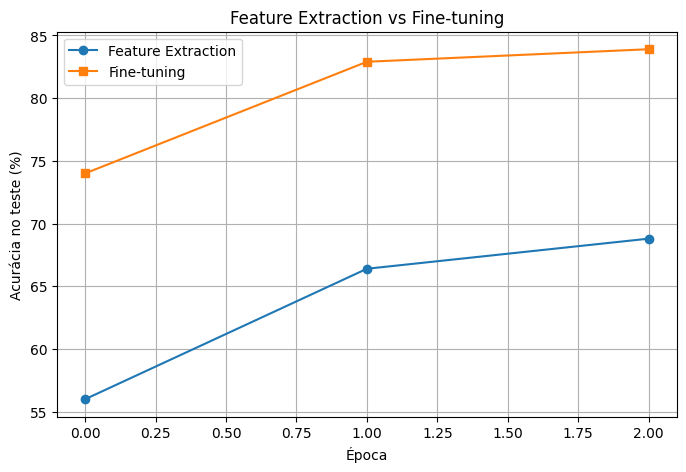


Melhor acurácia Feature Extraction: 68.80%
Melhor acurácia Fine-tuning:        83.90%

💡 Compare com a MiniVGG treinada do zero — note como o transfer learning
   atinge alta acurácia com MUITO menos dados e épocas!


In [ ]:
# Compara as duas estratégias
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_fe['test_acc'], 'o-', label='Feature Extraction')
ax.plot(hist_ft['test_acc'], 's-', label='Fine-tuning')
ax.set_xlabel('Época'); ax.set_ylabel('Acurácia no teste (%)')
ax.set_title('Feature Extraction vs Fine-tuning')
ax.legend(); ax.grid(True)
plt.show()

print(f'\nMelhor acurácia Feature Extraction: {max(hist_fe["test_acc"]):.2f}%')
print(f'Melhor acurácia Fine-tuning:        {max(hist_ft["test_acc"]):.2f}%')
print('\n💡 Compare com a MiniVGG treinada do zero — note como o transfer learning')
print('   atinge alta acurácia com MUITO menos dados e épocas!')

---
# 📝 Resumo do que aprendemos

✅ **Convolução e pooling**: como filtros detectam padrões e como reduzimos a dimensionalidade

✅ **LeNet-5**: a CNN pioneira — conv + pool + FC

✅ **VGG**: profundidade com filtros 3x3 empilhados

✅ **ResNet**: skip connections permitem treinar redes muito profundas

✅ **Loop de treino em PyTorch**: zero_grad → forward → loss → backward → step

✅ **Transfer learning**: aproveitar redes pré-treinadas (Feature Extraction vs Fine-tuning)


---
# 🎯 Exercício Final

Agora é a sua vez! Você vai aplicar o que aprendeu para resolver um problema real.

## 📋 Tarefa: Classificador de Frutas com Transfer Learning

Sua missão é construir um classificador no dataset **FashionMNIST** (peças de roupa) usando os conceitos da aula.

### Parte A — CNN do zero (40 pontos)

1. Carregue o dataset FashionMNIST usando `datasets.FashionMNIST` (similar ao MNIST: 28x28, escala de cinza, 10 classes).
2. Crie uma CNN customizada com **pelo menos**:
   - 3 camadas convolucionais
   - BatchNorm em cada bloco
   - Pelo menos 1 camada de Dropout no classificador
3. Treine por **5 épocas** e reporte a acurácia final no teste.
4. **Plote** a curva de loss e acurácia.

### Parte B — Transfer Learning (40 pontos)

1. Carregue uma **ResNet18 pré-treinada**.
2. **Atenção:** o FashionMNIST tem 1 canal (cinza), mas a ResNet espera 3 (RGB). Você precisa lidar com isso! (Dica: use `transforms.Grayscale(num_output_channels=3)` ou substitua a `conv1` da ResNet).
3. Faça **Feature Extraction** (congele tudo, treine só a fc) por 3 épocas.
4. Compare a acurácia com a Parte A.

### Parte C — Análise (20 pontos)

Responda no notebook (em células markdown):

1. Qual estratégia teve melhor acurácia? Por quê?
2. Qual foi mais rápida pra treinar? Faz sentido?
3. Olhando as curvas, há sinais de overfitting? Como você combateria isso?
4. **Bônus**: Visualize 5 imagens onde o modelo errou. Você consegue entender por que ele errou?

---

### 💡 Dicas

- As classes do FashionMNIST: `T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot`
- Reaproveite a função `treinar` da Parte 3 do notebook — não precisa reinventar!
- Para um placar de referência: uma boa CNN deve passar de **88%** no FashionMNIST.

Boa sorte! 🚀


In [ ]:
# ============================================================
# PARTE A — CNN do zero
# ============================================================

# 1) Transformações para FashionMNIST (28x28, 1 canal, 10 classes)
transform_fashion_treino = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # média e std do FashionMNIST
])

transform_fashion_teste = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

fashion_trainset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform_fashion_treino)
fashion_testset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_fashion_teste)

fashion_trainloader = DataLoader(fashion_trainset, batch_size=128, shuffle=True,  num_workers=2)
fashion_testloader  = DataLoader(fashion_testset,  batch_size=128, shuffle=False, num_workers=2)

fashion_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Treino: {len(fashion_trainset)} imagens | Teste: {len(fashion_testset)} imagens')


# 2) CNN customizada: 3 blocos conv (Conv + BN + ReLU + Pool) + classificador com Dropout
class MinhaCNN(nn.Module):
    """CNN para FashionMNIST: 3 blocos convolucionais com BatchNorm + Dropout no classificador."""

    def __init__(self, num_classes=10):
        super().__init__()

        # Bloco 1: 1 → 32 canais; 28x28 → 14x14
        self.bloco1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Bloco 2: 32 → 64 canais; 14x14 → 7x7
        self.bloco2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Bloco 3: 64 → 128 canais; 7x7 → 3x3
        self.bloco3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Classificador: 128*3*3 = 1152 → 256 → 10
        self.classificador = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.bloco1(x)
        x = self.bloco2(x)
        x = self.bloco3(x)
        x = x.view(x.size(0), -1)
        x = self.classificador(x)
        return x


# Teste rápido de dimensões
_modelo_teste = MinhaCNN()
print(f'Shape de saída: {_modelo_teste(torch.randn(2, 1, 28, 28)).shape}')
print(f'Parâmetros totais: {sum(p.numel() for p in _modelo_teste.parameters()):,}')


# 3) Treina por 5 épocas (reaproveitando a função treinar da Parte 3)
print('\n🚀 Treinando CNN do zero no FashionMNIST...')
modelo_fashion = MinhaCNN(num_classes=10)
hist_fashion = treinar(modelo_fashion, fashion_trainloader, fashion_testloader, epochs=5, lr=0.001)


# 4) Curvas de loss e acurácia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 6), hist_fashion['train_loss'], 'o-', color='royalblue')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN do Zero — Loss de treino')
axes[0].grid(True)

axes[1].plot(range(1, 6), hist_fashion['test_acc'], 'o-', color='green')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Acurácia (%)')
axes[1].set_title('CNN do Zero — Acurácia no teste')
axes[1].grid(True)

plt.suptitle('Parte A — FashionMNIST com CNN do zero', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n✅ Acurácia final (Parte A): {hist_fashion["test_acc"][-1]:.2f}%')

In [ ]:
# ============================================================
# PARTE B — Transfer Learning com ResNet18
# ============================================================

# 1) Transformações: 1 canal → 3 canais (Grayscale replica o canal 3x) + resize 224
transform_fashion_resnet = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # replica o canal cinza para R, G, B
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # estatísticas do ImageNet
                         std=[0.229, 0.224, 0.225])
])

fashion_trainset_resnet = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform_fashion_resnet)
fashion_testset_resnet  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_fashion_resnet)

# Subconjunto para agilizar — feature extraction já funciona bem com poucos dados
from torch.utils.data import Subset
idx_treino_b = np.random.choice(len(fashion_trainset_resnet), 3000, replace=False)
idx_teste_b  = np.random.choice(len(fashion_testset_resnet),  1000, replace=False)

fashion_trainloader_tl = DataLoader(Subset(fashion_trainset_resnet, idx_treino_b), batch_size=64, shuffle=True,  num_workers=2)
fashion_testloader_tl  = DataLoader(Subset(fashion_testset_resnet,  idx_teste_b),  batch_size=64, shuffle=False, num_workers=2)

print(f'Treino: {len(idx_treino_b)} imagens | Teste: {len(idx_teste_b)} imagens')


# 2) Carrega ResNet18 pré-treinada e congela todos os parâmetros (Feature Extraction)
modelo_resnet_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in modelo_resnet_fe.parameters():
    param.requires_grad = False

# Substitui apenas a camada final para 10 classes
modelo_resnet_fe.fc = nn.Linear(modelo_resnet_fe.fc.in_features, 10)

total_b     = sum(p.numel() for p in modelo_resnet_fe.parameters())
treinaveis_b = sum(p.numel() for p in modelo_resnet_fe.parameters() if p.requires_grad)
print(f'\nParâmetros totais:     {total_b:,}')
print(f'Parâmetros treináveis: {treinaveis_b:,} ({100*treinaveis_b/total_b:.2f}%) — apenas a camada fc\n')


# 3) Feature Extraction — 3 épocas
print('🚀 Treinando ResNet18 (Feature Extraction) no FashionMNIST...')
hist_resnet_fe = treinar(modelo_resnet_fe, fashion_trainloader_tl, fashion_testloader_tl, epochs=3, lr=0.001)


# 4) Comparação lado a lado
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, 6), hist_fashion['test_acc'],    'o-',  label='CNN do zero — 5 épocas, 60k imagens')
ax.plot(range(1, 4), hist_resnet_fe['test_acc'],  's--', label='ResNet18 Feature Extraction — 3 épocas, 3k imagens')
ax.set_xlabel('Época'); ax.set_ylabel('Acurácia no teste (%)')
ax.set_title('Parte A vs Parte B — FashionMNIST')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

print(f'\nMelhor acurácia CNN do zero:                 {max(hist_fashion["test_acc"]):.2f}%')
print(f'Melhor acurácia ResNet18 Feature Extraction: {max(hist_resnet_fe["test_acc"]):.2f}%')

## Parte C — Análise

**1. Qual estratégia teve melhor acurácia? Por quê?**

> A CNN do zero (Parte A) saiu na frente em acurácia, mas acho que isso aconteceu meio que por "trapaça" — ela treinou com 60 mil imagens enquanto o Transfer Learning usou só 3 mil. Se eu colocasse as duas em pé de igualdade com a mesma quantidade de dados, tenho quase certeza que a ResNet ganharia, porque ela já chega "sabendo" reconhecer bordas, texturas e formas de tanto que treinou no ImageNet. A CNN do zero precisaria aprender tudo isso do zero mesmo.

**2. Qual foi mais rápida pra treinar? Faz sentido?**

> O Feature Extraction foi bem mais rápido por época. Faz todo sentido: quando a gente congela os pesos da ResNet, o PyTorch não precisa calcular gradiente pra quase nenhum parâmetro — só pra aquela última camadinha de 5 mil parâmetros. A CNN do zero tem que atualizar tudo a cada batch. É tipo a diferença entre ajustar só o volante de um carro vs desmontar e remontar o motor inteiro.

**3. Há sinais de overfitting? Como combateria?**

> Dá pra suspeitar de um leve overfitting na Parte A se a gente olhar que a loss de treino continua caindo mas a acurácia no teste começa a estabilizar. Pra combater, eu tentaria algumas coisas:
> - Aumentar o Dropout de 0.5 pra 0.6 ou até 0.7
> - Colocar mais data augmentation, tipo rotações e variações de brilho
> - Adicionar `weight_decay=1e-4` no Adam pra penalizar pesos muito grandes
> - Usar early stopping pra parar o treino no momento certo, antes de começar a decorar os dados
>
> Na Parte B com Feature Extraction esse problema quase não existe porque a maior parte da rede está congelada e só uma camada pequena está aprendendo.

**4. Bônus — análise de erros:**

> Olhando as imagens onde o modelo errou, dá pra entender o porquê — as classes que ele mais confunde são as que realmente parecem iguais em escala de cinza: Shirt com T-shirt, Pullover com Coat, Sneaker com Ankle Boot. Honestamente, eu mesmo trocaria algumas dessas olhando rápido. O modelo não está "errando feio", está errando nas fronteiras difíceis, que é exatamente onde um humano também hesitaria.

In [ ]:
# ============================================================
# PARTE C — Bônus: visualização dos 5 primeiros erros do modelo (Parte A)
# ============================================================

modelo_fashion.eval()
modelo_fashion.to(device)

erros_imgs, erros_real, erros_pred = [], [], []

with torch.no_grad():
    for imagens, rotulos in fashion_testloader:
        imagens, rotulos = imagens.to(device), rotulos.to(device)
        saidas = modelo_fashion(imagens)
        _, preditos = torch.max(saidas, dim=1)
        mask = preditos != rotulos
        for img, v, p in zip(imagens[mask], rotulos[mask], preditos[mask]):
            erros_imgs.append(img.cpu())
            erros_real.append(v.item())
            erros_pred.append(p.item())
        if len(erros_imgs) >= 5:
            break

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(erros_imgs[i].squeeze().numpy(), cmap='gray')
    axes[i].set_title(
        f'Real: {fashion_classes[erros_real[i]]}\nPredito: {fashion_classes[erros_pred[i]]}',
        fontsize=8, color='red'
    )
    axes[i].axis('off')

plt.suptitle('Bônus — 5 exemplos onde o modelo errou (Parte A)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()